In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Salary_Data.csv')

X = df["YearsExperience"].values
Y = df["Salary"].values

In [16]:
X = np.array(X)
Y = np.array(Y)

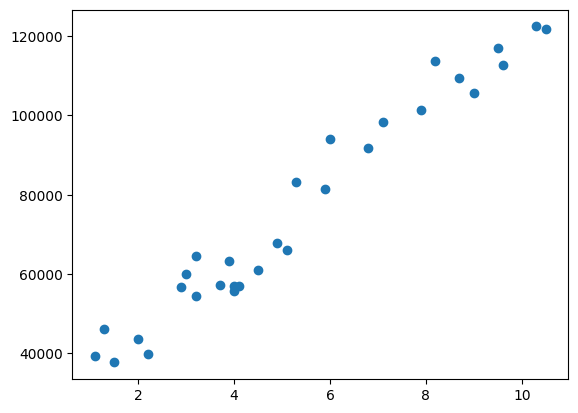

In [17]:
plt.scatter(X,Y)
plt.show()

Epoch: 0
Loss: 6502955270.733334
Epoch: 50
Loss: 3186417688.139748
Epoch: 100
Loss: 1601922538.1839087
Epoch: 150
Loss: 844781253.8180302
Epoch: 200
Loss: 482847053.3942722
Epoch: 250
Loss: 309694377.95203674
Epoch: 300
Loss: 226718970.16071856
Epoch: 350
Loss: 186820073.11002606
Epoch: 400
Loss: 167498845.43479875
Epoch: 450
Loss: 158008156.70377895
Epoch: 500
Loss: 153214370.68190596
Epoch: 550
Loss: 150665274.91902527
Epoch: 600
Loss: 149189505.09992513
Epoch: 650
Loss: 148227525.58837655
Epoch: 700
Loss: 147512055.80572623
Epoch: 750
Loss: 146915418.01933834
Epoch: 800
Loss: 146376619.25378403
Epoch: 850
Loss: 145866520.1696412
Epoch: 900
Loss: 145371197.1204689
Epoch: 950
Loss: 144883994.62944233
Final m: 12836.600965885045 Final b: 2915.204485601402


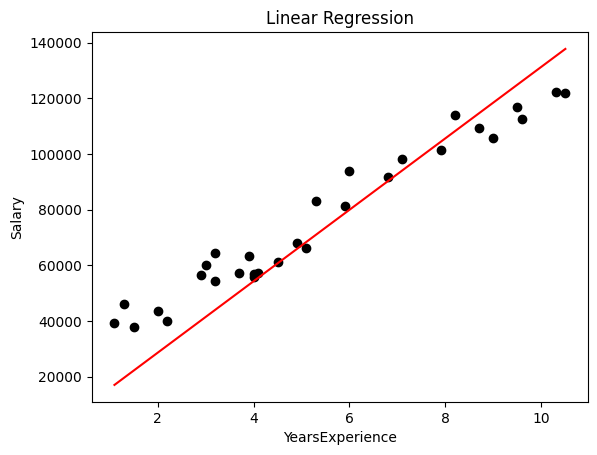

In [18]:
def loss_function (m, b, points):
  total_error = 0
  for i in range(len(points)):
    x = points.iloc[i].X
    y = points.iloc[i].Y
    total_error += (y - (m * x + b)) ** 2
  return total_error / float(len(points))


def gradient_descent(m_now, b_now, points, L):
  m_gradient = 0
  b_gradient = 0

  n = len(points)

  for i in range(n):
    X_val = points.iloc[i].X
    Y_val = points.iloc[i].Y

    m_gradient += -(2/n) * X_val * (Y_val - (m_now * X_val + b_now))
    b_gradient += -(2/n) * (Y_val - (m_now * X_val + b_now))


  m = m_now - m_gradient * L
  b = b_now - b_gradient * L
  return m, b
m = 0
b = 0
L = 0.0001
epochs = 1000


data = pd.DataFrame({'X': X, 'Y': Y})

for i in range(epochs):
  if i % 50 == 0:
    print(f"Epoch: {i}")
    print(f"Loss: {loss_function(m, b, data)}") #\
  m, b = gradient_descent(m, b, data, L)

print("Final m:", m, "Final b:", b)

plt.scatter(data['X'], data['Y'], color="black")

x_line = np.linspace(X.min(), X.max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, color="red")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.show()
